In [5]:
import sys
sys.path.append('../')
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from models.reward_network import RewardNetwork # We can inherit to reuse some methods
from utils import unwrap_state
from config import DEVICE
from typing_extensions import override

from utils import ten

class RewardCNN(nn.Module):
    def __init__(self, input_channels: int, height: int, width: int, alpha: float, mlp_hidden_features: int = 128):
        """Convolutional Neural Network for Reward Prediction

        Args:
            input_channels: Number of input channels (3 using using architecture provided in CNN pdf)
            height: Height of the input images
            width: Width of the input images
            alpha: Learning rate for the optimizer
            hidden_dim: Not used in CNN layers but used in the MLP head after convolutions.
        """
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Calculate the size of the flattened layer after convolutions and pooling
        # This is a robust way to handle different input sizes
        conv_output_size = self._get_conv_output_size(input_channels, height, width)
        self.mlp_head = nn.Sequential(
            nn.Linear(conv_output_size, mlp_hidden_features),
            nn.ReLU(),
            nn.Linear(mlp_hidden_features, 1)
        )

        # use all parameters of the model
        self.optimizer = torch.optim.Adam(self.parameters(), lr=alpha)

        self.batch_states = []
        self.batch_rewards = []
        self.loss_history = []


    def forward(self, x: Tensor) -> Tensor:
        """Defines the forward pass of the data through the network."""
        features = self.pool1(F.relu(self.conv1(x)))
        features = self.pool2(F.relu(self.conv2(features)))
        feature_vector = torch.flatten(features, 1)
        prediction = self.mlp_head(feature_vector)
        return prediction
    

    def _get_conv_output_size(self, input_channels: int, height: int, width: int) -> int:
        """Get the number of features after the conv and pooling layers

        Args:
            input_channels: Number of input channels
            height: Height of the input images
            width: Width of the input images

        Returns:
            The number of features after the conv and pooling layers
        """
        # Create a dummy tensor and pass it through the conv layers to find the output size
        with torch.no_grad():
            x: Tensor = torch.zeros(1, input_channels, height, width)
            x = self.pool1(F.relu(self.conv1(x)))
            x = self.pool2(F.relu(self.conv2(x)))
            return x.numel() # Total number of elements
        
    def get_model_reward_prediction(self, x) -> np.ndarray:
            # x is a single numpy array of shape [channels, height, width]
            
            # Convert to a PyTorch tensor and add a batch dimension of 1
            state_input_tensor = ten(x, DEVICE).unsqueeze(0) # unsqueeze(0) adds the batch dim, shape becomes [1, C, H, W]

            with torch.no_grad():
                reward_prediction = self.forward(state_input_tensor)
            return reward_prediction.cpu().numpy()
    
    def train_batch(self):
        """Train the CNN model on the current batch of states and rewards. Note by batch we mean mini-batch training.

        Preconditions:
            - self.batch_states and self.batch_rewards are populated with experiences. This must be done using ViewControllerCNN to ensure correct state shape.

        Returns:
            The loss value for this training step
        """
        if len(self.batch_states) == 0:
            return None

        # self.batch_states is a list of numpy arrays with shape [channels, height, width]
        # Stack them into a single numpy array of shape [batch_size, channels, height, width]
        states_np = np.stack(self.batch_states, axis=0)
        states_tensor = ten(states_np, DEVICE)

        # Targets are the rewards
        targets = ten(np.asarray(self.batch_rewards, dtype=np.float64), DEVICE).view(-1) # view is just in case
        preds = self.forward(states_tensor).view(-1) # Final predictions, view to ensure shape is [batch_size]
        # --- End of Forward Pass ---

        criterion = torch.nn.MSELoss()
        self.optimizer.zero_grad()
        loss = criterion(preds, targets)
        loss.backward()
        self.optimizer.step()

        self.batch_states.clear()
        self.batch_rewards.clear()
        loss_val = float(loss.detach().cpu().item())
        self.loss_history.append(loss_val)
        return loss_val
    
    def _raw_state_to_nn_input(self, state: dict, agent_pos: np.ndarray, agent_id=None) -> np.ndarray:
        """
        Transforms state into a (3, height, width) numpy array for a CNN.

        - Channel 0: Apples (1 where apples exist, 0 otherwise)
        - Channel 1: Other agents
        - Channel 2: The current agent (one-hot encoded position)
        """
        agents_map, apples_map = unwrap_state(state) # Your helper from helpers.py
        height, width = agents_map.shape

        # Channel 0: Apples
        channel_apples = apples_map

        # Create a map for just the current agent
        self_agent_map = np.zeros_like(agents_map, dtype=np.float32)
        if agent_pos is not None:
            self_agent_map[agent_pos[0], agent_pos[1]] = 1.0
        else:
            raise ValueError("agent_pos must be provided for CNN input.")

        # Channel 1: Other agents
        channel_others = agents_map.astype(np.float32) - self_agent_map

        # Channel 2: Current agent
        channel_self_agent = self_agent_map

        # Stack the channels to create the final "image"
        # The shape is (channels, height, width), which PyTorch expects
        cnn_state = np.stack([channel_apples, channel_others, channel_self_agent], axis=0)

        return cnn_state

    def add_experience_from_raw(self, raw_state: dict, agent_pos: np.ndarray, reward: float):
        """Processes a raw state and adds the experience to the training buffer.
        
        Args:
            raw_state: dict with keys "agents" and "apples" with values as 2D numpy arrays.
            agent_pos: The (row, col) position of the agent in the grid.
            reward: The reward received after taking an action.
        """
        processed_state = self._raw_state_to_nn_input(raw_state, agent_pos)
        self.batch_states.append(processed_state)
        self.batch_rewards.append(reward)

In [ ]:
import torch
import numpy as np

from utils import unwrap_state
from config import DEVICE
from utils import ten

# --- 1. Define the parameters of our test ---
HEIGHT = 9
WIDTH = 9
NUM_CHANNELS = 3
BATCH_SIZE = 32

# --- 2. Instantiate your NEW self-contained RewardCNN ---
# We no longer create a ViewControllerCNN
reward_cnn = RewardCNN(
    input_channels=NUM_CHANNELS,
    height=HEIGHT,
    width=WIDTH,
    alpha=0.001, # A good starting learning rate
    mlp_hidden_features=64
)

# --- 3. Create a fake batch of experiences using the NEW method ---
for _ in range(BATCH_SIZE):
    # Create a random RAW state (this part is the same)
    fake_raw_state = {
        'agents': np.random.randint(0, 2, size=(HEIGHT, WIDTH)),
        'apples': np.random.randint(0, 2, size=(HEIGHT, WIDTH))
    }
    fake_agent_pos = np.array([np.random.randint(HEIGHT), np.random.randint(WIDTH)])
    
    # Create a random reward
    fake_reward = np.random.rand()
    
    # --- THE KEY CHANGE ---
    # Call the new method that handles processing internally
    reward_cnn.add_experience_from_raw(fake_raw_state, fake_agent_pos, fake_reward)

# --- 4. Run the train method ONCE ---
# NOTE: Make sure your train method is named train_batch()
print(f"Number of states in batch: {len(reward_cnn.batch_states)}")
loss = reward_cnn.train_batch()
print(f"Training step completed successfully!")
print(f"Calculated Loss: {loss}")
print(f"Number of states in batch after training: {len(reward_cnn.batch_states)}")

Number of states in batch: 32
Training step completed successfully!
Calculated Loss: 0.36058056242751346
Number of states in batch after training: 0


Epoch 0/100, Loss: 2.1333461008044826e-05
Epoch 10/100, Loss: 2.3099593137614356e-07
Epoch 20/100, Loss: 3.528081705320851e-06
Epoch 30/100, Loss: 2.9104548159624917e-07
Epoch 40/100, Loss: 2.5510085988102024e-07
Epoch 50/100, Loss: 1.0841719868287603e-07
Epoch 60/100, Loss: 1.1224277698657267e-08
Epoch 70/100, Loss: 1.856379550666788e-08
Epoch 80/100, Loss: 4.96537705015624e-10
Epoch 90/100, Loss: 2.3699937066426114e-09


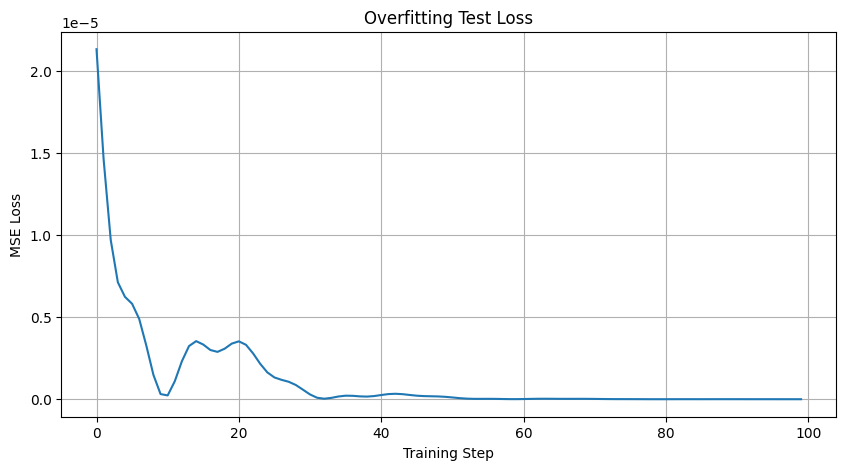


--- Final Predictions ---
Prediction for 'Reward=1' state: 1.0000 (Target was 1.0)
Prediction for 'Reward=0' state: -0.0000 (Target was 0.0)


In [10]:
import matplotlib.pyplot as plt

# --- 1. Create a "perfect" but tiny dataset ---
# We still define the RAW states
state_one_raw = {'agents': np.zeros((HEIGHT, WIDTH)), 'apples': np.zeros((HEIGHT, WIDTH))}
state_one_raw['agents'][4, 4] = 1 # Self-agent
state_one_raw['apples'][4, 4] = 1 # Apple at same spot
pos_one = np.array([4, 4])
reward_one = 1.0

state_zero_raw = {'agents': np.zeros((HEIGHT, WIDTH)), 'apples': np.zeros((HEIGHT, WIDTH))}
state_zero_raw['agents'][1, 1] = 1 # Self-agent
state_zero_raw['apples'][8, 8] = 1 # Apple far away
pos_zero = np.array([1, 1])
reward_zero = 0.0

# --- 2. Train on this tiny dataset for many epochs ---
loss_history = []
epochs = 100
for i in range(epochs):
    # --- THE KEY CHANGE ---
    # Add the RAW experiences to the buffer
    reward_cnn.add_experience_from_raw(state_one_raw, pos_one, reward_one)
    reward_cnn.add_experience_from_raw(state_zero_raw, pos_zero, reward_zero)
    
    # Train on this tiny batch
    loss = reward_cnn.train_batch()
    loss_history.append(loss)
    if i % 10 == 0:
        print(f"Epoch {i}/{epochs}, Loss: {loss}")

# --- 3. Visualize the result (this part is the same) ---
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title("Overfitting Test Loss")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# --- 4. Check the final predictions ---
# NOTE: We need to manually process the state for the final check,
# because get_model_reward_prediction expects the processed image, not the raw dict.
processed_input_one = reward_cnn._raw_state_to_nn_input(state_one_raw, pos_one)
processed_input_zero = reward_cnn._raw_state_to_nn_input(state_zero_raw, pos_zero)

print("\n--- Final Predictions ---")
pred_one = reward_cnn.get_model_reward_prediction(processed_input_one)
print(f"Prediction for 'Reward=1' state: {pred_one.item():.4f} (Target was 1.0)")

pred_zero = reward_cnn.get_model_reward_prediction(processed_input_zero)
print(f"Prediction for 'Reward=0' state: {pred_zero.item():.4f} (Target was 0.0)")